In [15]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

In [16]:
sb_hist = pd.read_csv("sb_history.csv", index_col=["Date"], parse_dates=["Date"])
sb_test = pd.read_csv("sb_test.csv", index_col=["Date"], parse_dates=["Date"])

In [ ]:
def evaluate_arima_model(X, train_ratio, arima_order, trend):
    train_size = int(len(X) * train_ratio)
    train, test = X[0:train_size], X[train_size:]  # initial split of train and tes
    model = ARIMA(
        X[:train_size], order=arima_order, trend=trend
    )  # each step: rolling one step forward to update the train set
    model_fit = model.fit()
    predictions = model_fit.forecast(len(test))
    rmse = np.sqrt(mean_squared_error(test, predictions))
    return rmse


def evaluate_models(dataset, train_ratio, p_values, d_values, q_values, trend_values):
    result = []
    best_rmse, best_cfg, best_trend = float("inf"), None, None
    for p in p_values:
        for d in d_values:
            for q in q_values:
                for trend in trend_values:
                    try:
                        order = (p, d, q)
                        rmse = evaluate_arima_model(dataset, train_ratio, order, trend)
                        result.append((order, rmse))
                        if rmse < best_rmse:
                            best_rmse, best_cfg, best_trend = rmse, order, trend
                    # print('ARIMA%s RMSE=%.3f' % (order,rmse))
                    except:
                        continue
    print("Best ARIMA%s RMSE=%.3f" % (best_cfg, best_rmse))
    print("Best trend: ", best_trend)
    return best_cfg, best_trend

In [18]:
p_values = [0, 1, 2, 3]
d_values = [0, 1, 2, 3]
q_values = [0, 1, 2, 3]
trend_values = ["n", [1, 1, 1, 1]]
best_cfg, best_trend = evaluate_models(
    sb_hist, 0.8, p_values, d_values, q_values, trend_values
)
p, d, q = best_cfg
model = ARIMA(sb_hist, order=(p, d, q), trend=best_trend)
results = model.fit()
# print(results.summary())

Best ARIMA(2, 3, 1) RMSE=1.656
Best trend:  n


In [19]:
preds = results.forecast(steps=len(sb_test))
preds

130    16.502476
131    16.987521
132    17.530255
133    18.077139
134    18.613019
135    19.161041
136    19.710302
137    20.261900
138    20.817886
139    21.376679
140    21.938768
141    22.504240
Name: predicted_mean, dtype: float64

In [20]:
rmse = np.sqrt(mean_squared_error(sb_test["Adj Close"].values, preds))
print(f"Test RMSE: {rmse}")

Test RMSE: 3.02184225072473


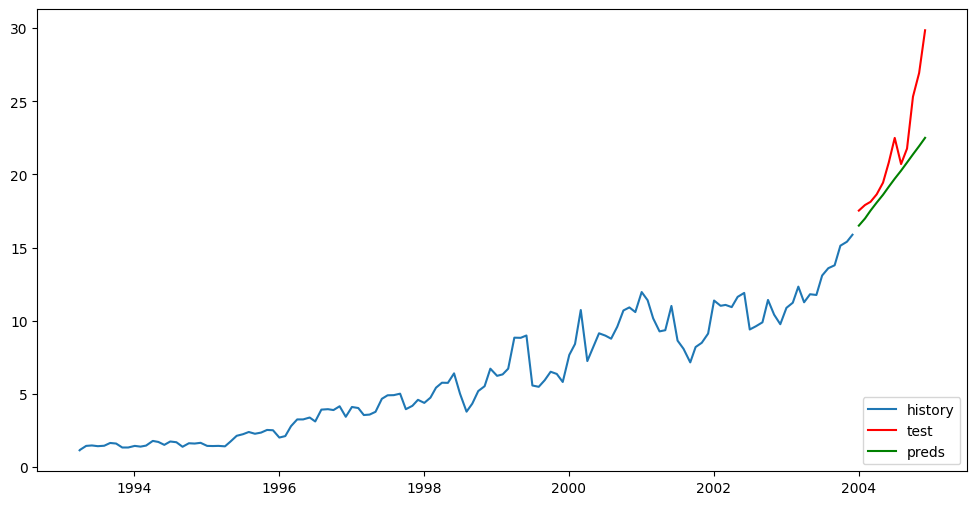

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(sb_hist.index, sb_hist["Adj Close"], label="history")
ax.plot(sb_test.index, sb_test["Adj Close"], label="test", color="red")
ax.plot(sb_test.index, preds, label="preds", color="green")
ax.legend(loc="lower right")
plt.show()